In [ ]:
# ================================================================
# CELL 0 — SETUP + PUBLICATION-CLEAN 72/8/20 PROTOCOL + ORIGINAL OUTPUT NAMES
# ================================================================
# This notebook is the corrected centralized Binary DL workflow.
#
# Methodology:
#   - Existing saved CSV split remains the original 80% train / 20% test.
#   - The original 80% training partition is split again:
#       90% -> actual model training = 72% overall
#       10% -> validation            =  8% overall
#   - StandardScaler is fitted ONLY on the actual 72% training samples.
#   - Validation and test are transformed only.
#
# Shared protocol files saved to Drive are tiny:
#   - validation indices
#   - StandardScaler
#   - protocol manifest
# No large standardized train/validation/test arrays are saved to Drive.
# ================================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
import gc
import re
import time
import json
import shutil
import subprocess
import sys
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib

from IPython.display import display
from matplotlib.colors import PowerNorm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from tensorflow.keras import mixed_precision

matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

RANDOM_SEED = 42
VALIDATION_FRACTION_OF_ORIGINAL_TRAIN = 0.10
PROTOCOL_NAME = 'binary_72_8_20_train_only_scaler_v1'

tf.keras.utils.set_random_seed(RANDOM_SEED)

GPU_DEVICES = tf.config.list_physical_devices('GPU')
for gpu_device in GPU_DEVICES:
    try:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    except RuntimeError:
        pass

if GPU_DEVICES:
    mixed_precision.set_global_policy('mixed_float16')
else:
    mixed_precision.set_global_policy('float32')

print('TensorFlow version:', tf.__version__)
print('GPU devices:', GPU_DEVICES)
print('Precision policy:', mixed_precision.global_policy())

# ------------------------------------------------------------------
# Original saved binary split — SAME SOURCE NAMES AS BEFORE
# ------------------------------------------------------------------
OUT_PATH = '/content/drive/MyDrive/IoMT_Thesis_2024'
TRAIN_FILE = f'{OUT_PATH}/dl_train_full.csv'
TEST_FILE = f'{OUT_PATH}/dl_test_full.csv'

# ------------------------------------------------------------------
# SAME Binary DL output names/folders as the original notebook
# ------------------------------------------------------------------
RESULT_FILE = f'{OUT_PATH}/binary_dl_results.csv'
MODEL_DIR = f'{OUT_PATH}/binary_dl_models'
HISTORY_DIR = f'{OUT_PATH}/binary_dl_history'
PLOT_DIR = f'{OUT_PATH}/binary_dl_conference_plots'
CACHE_DIR = f'{OUT_PATH}/binary_dl_prediction_cache'
BACKUP_DIR = f'{OUT_PATH}/binary_dl_training_backups'
REPORT_DIR = f'{OUT_PATH}/binary_dl_classification_reports'
PREPROCESSED_DIR = f'{OUT_PATH}/binary_dl_preprocessed'
NETRON_EXPORT_DIR = f'{OUT_PATH}/binary_dl_netron_exports'

XAI_DIR = f'{OUT_PATH}/binary_lime_vs_shap'
MCNEMAR_OUTPUT_FILE = f'{OUT_PATH}/binary_dl_best_vs_other_models_mcnemar_holm.csv'

# ------------------------------------------------------------------
# Corrected preprocessing metadata in the SAME preprocessed folder.
# Large standardized feature matrices are NOT saved to Drive.
# ------------------------------------------------------------------
VALIDATION_INDEX_FILE = f'{PREPROCESSED_DIR}/validation_indices.npy'
SCALER_FILE = f'{PREPROCESSED_DIR}/StandardScaler.joblib'
FEATURE_NAMES_FILE = f'{PREPROCESSED_DIR}/feature_names.npy'
PROTOCOL_MANIFEST_FILE = f'{PREPROCESSED_DIR}/protocol_manifest.json'

# Old giant cache names are only detected/ignored; never created here.
LEGACY_X_TRAIN_SCALED_FILE = f'{PREPROCESSED_DIR}/X_train_scaled_float32.npy'
LEGACY_X_TEST_SCALED_FILE = f'{PREPROCESSED_DIR}/X_test_scaled_float32.npy'

for folder in [
    MODEL_DIR,
    HISTORY_DIR,
    PLOT_DIR,
    CACHE_DIR,
    BACKUP_DIR,
    REPORT_DIR,
    PREPROCESSED_DIR,
    NETRON_EXPORT_DIR,
    XAI_DIR
]:
    os.makedirs(folder, exist_ok=True)

print('\nTraining CSV exists:', os.path.exists(TRAIN_FILE))
print('Testing CSV exists :', os.path.exists(TEST_FILE))
print('Binary output names : ORIGINAL names preserved')
print('Preprocessed folder :', PREPROCESSED_DIR)
print('\nSPACE-SAVER: standardized feature arrays are kept in Colab RAM only.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Precision policy: <DTypePolicy "mixed_float16">

Training CSV exists: True
Testing CSV exists : True
Binary output names : ORIGINAL names preserved
Preprocessed folder : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed

SPACE-SAVER: standardized feature arrays are kept in Colab RAM only.


In [ ]:
# ================================================================
# CELL 1 — CREATE / LOAD THE SHARED 72/8/20 PREPROCESSING PROTOCOL
# ================================================================
# The validation row indices are shared with the Federated Learning
# notebook.  The scaler is estimated ONLY from the actual training rows.
# Large transformed arrays remain in Colab RAM in this DL notebook.
# ================================================================

if not os.path.exists(TRAIN_FILE) or not os.path.exists(TEST_FILE):
    raise FileNotFoundError(
        'The binary DL train/test CSV files were not found.\n'
        f'Train: {TRAIN_FILE}\n'
        f'Test : {TEST_FILE}'
    )

# ---------------------------------------------------------------
# Legacy large standardized arrays are NOT loaded by this notebook.
# This prevents the old preprocessing protocol from being reused.
# ---------------------------------------------------------------
legacy_large_files = [
    LEGACY_X_TRAIN_SCALED_FILE,
    LEGACY_X_TEST_SCALED_FILE
]
existing_legacy_large_files = [p for p in legacy_large_files if os.path.exists(p)]
if existing_legacy_large_files:
    print('\nWARNING: Old large standardized cache files were found, but they are IGNORED:')
    for p in existing_legacy_large_files:
        print('  ', p)
    print('You may delete those old .npy files after confirming the new workflow.')

# ---------------------------------------------------------------
# Load original 80% train and untouched 20% test CSVs
# ---------------------------------------------------------------
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

if 'Label' not in train_df.columns or 'Label' not in test_df.columns:
    raise ValueError("Both CSV files must contain a 'Label' column.")

y_train_full = train_df.pop('Label').to_numpy(dtype=np.int8, copy=True)
y_test = test_df.pop('Label').to_numpy(dtype=np.int8, copy=True)

train_df = train_df.astype(np.float32, copy=False)
test_df = test_df.astype(np.float32, copy=False)

if train_df.columns.tolist() != test_df.columns.tolist():
    raise ValueError('Train/test feature columns do not match exactly.')

feature_names = train_df.columns.astype(str).tolist()
num_train_full = len(y_train_full)
num_test = len(y_test)
num_features = train_df.shape[1]

expected_manifest = {
    'protocol_name': PROTOCOL_NAME,
    'random_seed': int(RANDOM_SEED),
    'validation_fraction_of_original_train': float(VALIDATION_FRACTION_OF_ORIGINAL_TRAIN),
    'original_train_rows': int(num_train_full),
    'test_rows': int(num_test),
    'num_features': int(num_features),
    'train_class_counts': np.bincount(y_train_full, minlength=2).astype(int).tolist(),
    'test_class_counts': np.bincount(y_test, minlength=2).astype(int).tolist(),
    'feature_names': feature_names
}

# ---------------------------------------------------------------
# Load or create the shared validation indices
# ---------------------------------------------------------------
if os.path.exists(VALIDATION_INDEX_FILE):
    validation_indices = np.load(VALIDATION_INDEX_FILE, allow_pickle=False).astype(np.int32)
    print('Loaded existing shared validation indices.')
else:
    all_indices = np.arange(num_train_full, dtype=np.int32)
    training_indices_tmp, validation_indices = train_test_split(
        all_indices,
        test_size=VALIDATION_FRACTION_OF_ORIGINAL_TRAIN,
        random_state=RANDOM_SEED,
        stratify=y_train_full
    )
    validation_indices = np.sort(validation_indices.astype(np.int32, copy=False))
    np.save(VALIDATION_INDEX_FILE, validation_indices, allow_pickle=False)
    del all_indices, training_indices_tmp
    print('Created shared validation indices.')

if validation_indices.ndim != 1:
    raise ValueError('Validation indices must be one-dimensional.')
if len(validation_indices) == 0:
    raise ValueError('Validation split is empty.')
if validation_indices.min() < 0 or validation_indices.max() >= num_train_full:
    raise ValueError('Validation indices are outside the original training range.')
if len(np.unique(validation_indices)) != len(validation_indices):
    raise ValueError('Duplicate validation indices detected.')

is_validation = np.zeros(num_train_full, dtype=bool)
is_validation[validation_indices] = True
training_indices = np.flatnonzero(~is_validation).astype(np.int32, copy=False)

# ---------------------------------------------------------------
# Validate or create manifest
# ---------------------------------------------------------------
if os.path.exists(PROTOCOL_MANIFEST_FILE):
    with open(PROTOCOL_MANIFEST_FILE, 'r') as f:
        saved_manifest = json.load(f)
    if saved_manifest != expected_manifest:
        raise RuntimeError(
            'Shared binary protocol manifest does not match the current CSV data.\n'
            'Do not continue with mixed datasets. If the source CSVs were intentionally '\
            'changed, create a new shared protocol folder.'
        )
else:
    with open(PROTOCOL_MANIFEST_FILE, 'w') as f:
        json.dump(expected_manifest, f, indent=2)
    print('Created shared protocol manifest.')

# ---------------------------------------------------------------
# Fit StandardScaler ONLY on actual training rows.
# Chunked partial_fit avoids a second full-size fitting copy.
# ---------------------------------------------------------------
train_matrix = train_df.to_numpy(dtype=np.float32, copy=False)
test_matrix = test_df.to_numpy(dtype=np.float32, copy=False)

scaler = StandardScaler()
SCALER_FIT_CHUNK = 250_000
for start in range(0, len(training_indices), SCALER_FIT_CHUNK):
    idx_chunk = training_indices[start:start + SCALER_FIT_CHUNK]
    scaler.partial_fit(train_matrix[idx_chunk])

joblib.dump(scaler, SCALER_FILE)
np.save(
    FEATURE_NAMES_FILE,
    np.asarray(feature_names, dtype=object),
    allow_pickle=True
)
print('Scaler fitted on actual training rows only.')
print('Feature names saved:', FEATURE_NAMES_FILE)

# ---------------------------------------------------------------
# Transform actual train, validation, and test separately
# ---------------------------------------------------------------
X_train_scaled = scaler.transform(train_matrix[training_indices]).astype(np.float32, copy=False)
X_val_scaled = scaler.transform(train_matrix[validation_indices]).astype(np.float32, copy=False)
X_test_scaled = scaler.transform(test_matrix).astype(np.float32, copy=False)

y_train = y_train_full[training_indices].astype(np.int8, copy=False)
y_val = y_train_full[validation_indices].astype(np.int8, copy=False)
y_test = np.asarray(y_test, dtype=np.int8).reshape(-1)

# Sequence arrays are views; they do not duplicate the feature matrices.
X_train_seq = X_train_scaled[..., np.newaxis]
X_val_seq = X_val_scaled[..., np.newaxis]
X_test_seq = X_test_scaled[..., np.newaxis]

# ---------------------------------------------------------------
# Publication-methodology checks
# ---------------------------------------------------------------
total_rows = len(y_train) + len(y_val) + len(y_test)

print('\n' + '=' * 72)
print('BINARY DL 72/8/20 PROTOCOL — VERIFIED')
print('=' * 72)
print('Actual training :', f'{len(y_train):,}', f'({len(y_train)/total_rows:.2%})')
print('Validation      :', f'{len(y_val):,}', f'({len(y_val)/total_rows:.2%})')
print('Held-out test   :', f'{len(y_test):,}', f'({len(y_test)/total_rows:.2%})')
print('Features        :', len(feature_names))
print('Train labels    :', pd.Series(y_train).value_counts().sort_index().to_dict())
print('Validation labels:', pd.Series(y_val).value_counts().sort_index().to_dict())
print('Test labels     :', pd.Series(y_test).value_counts().sort_index().to_dict())
print('\nScaler FIT      : actual 72% training rows only')
print('Scaler TRANSFORM: validation + test')
print('Validation index file       :', VALIDATION_INDEX_FILE)
print('Scaler file                 :', SCALER_FILE)
print('No standardized arrays were written to Google Drive.')
print('=' * 72)

# Release raw CSV data after preprocessing.
del train_df, test_df, train_matrix, test_matrix, y_train_full
# training_indices/validation_indices are tiny enough to keep if needed.
gc.collect()


Loaded existing shared validation indices.
Scaler fitted on actual training rows only.
Feature names saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/feature_names.npy

BINARY DL 72/8/20 PROTOCOL — VERIFIED
Actual training : 2,338,102 (72.00%)
Validation      : 259,790 (8.00%)
Held-out test   : 649,474 (20.00%)
Features        : 79
Train labels    : {0: 23467, 1: 2314635}
Validation labels: {0: 2607, 1: 257183}
Test labels     : {0: 6519, 1: 642955}

Scaler FIT      : actual 72% training rows only
Scaler TRANSFORM: validation + test
Validation index file       : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/validation_indices.npy
Scaler file                 : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/StandardScaler.joblib
No standardized arrays were written to Google Drive.


11

In [ ]:
# ================================================================
# TRAINING CONFIGURATION — ALL MODELS CAN RUN IN THIS RUNTIME
# ================================================================

EPOCHS = 100
SHOW_PLOTS = True
PRESERVE_EXISTING_RESULT_ROWS = True

MODEL_ORDER = [
    'FNN',
    'CNN',
    'RNN',
    'GRU',
    'LSTM',
    'CNN-LSTM',
    'CNN-LSTM-ResNet'
]

# T4-oriented batch sizes. If one architecture raises an OOM error,
# reduce only that architecture's value by half and rerun its cell.
MODEL_BATCH_SIZES = {
    'FNN': 8192,
    'CNN': 4096,
    'RNN': 4096,
    'GRU': 4096,
    'LSTM': 4096,
    'CNN-LSTM': 4096,
    'CNN-LSTM-ResNet': 2048
}

PREDICTION_BATCH_SIZES = {
    model_name: max(batch_size, 8192)
    for model_name, batch_size in MODEL_BATCH_SIZES.items()
}

RESULT_COLUMNS = [
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC AUC', 'Average Precision', 'Train Time'
]

if os.path.exists(RESULT_FILE):
    dl_results_df = pd.read_csv(RESULT_FILE)
    print('Previous binary DL results loaded.')
else:
    dl_results_df = pd.DataFrame(columns=RESULT_COLUMNS)
    print('New binary DL result table created.')


def safe_file_name(value):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value)).strip('_')


def artifact_paths(name):
    safe_name = safe_file_name(name)
    return {
        'model': os.path.join(MODEL_DIR, f'{safe_name}.keras'),
        'best_weights': os.path.join(MODEL_DIR, f'{safe_name}_best.weights.h5'),
        'cache': os.path.join(CACHE_DIR, f'{safe_name}_predictions.npz'),
        'history': os.path.join(HISTORY_DIR, f'{safe_name}_history.csv'),
        'backup': os.path.join(BACKUP_DIR, safe_name),
        'report': os.path.join(REPORT_DIR, f'{safe_name}_classification_report.csv')
    }


def result_row_exists(name):
    if not os.path.exists(RESULT_FILE):
        return False

    table = pd.read_csv(RESULT_FILE)
    return (
        'Model' in table.columns
        and name in table['Model'].astype(str).values
    )


def model_is_complete(name):
    paths = artifact_paths(name)
    return (
        os.path.exists(paths['model'])
        and os.path.exists(paths['cache'])
        and result_row_exists(name)
    )


def compile_binary_model(model):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy'],
        steps_per_execution=32
    )
    return model


def show_or_close(fig):
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

print('Epoch ceiling:', EPOCHS)
print('Model-specific batch sizes:', MODEL_BATCH_SIZES)
print('Validation protocol: explicit 72/8/20 split; scaler fit on train only.')
print('All unfinished model cells may run sequentially in this runtime.')


Previous binary DL results loaded.
Epoch ceiling: 100
Model-specific batch sizes: {'FNN': 8192, 'CNN': 4096, 'RNN': 4096, 'GRU': 4096, 'LSTM': 4096, 'CNN-LSTM': 4096, 'CNN-LSTM-ResNet': 2048}
Validation protocol: explicit 72/8/20 split; scaler fit on train only.
All unfinished model cells may run sequentially in this runtime.


In [ ]:
# ================================================================
# BACKUP, TRAINING, SAVING, METRICS, AND PNG-ONLY PLOTTING
# ================================================================


def calculate_binary_metrics(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=np.int8).reshape(-1)
    y_prob = np.asarray(y_prob, dtype=np.float32).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(np.int8)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    precision_values, recall_values, _ = precision_recall_curve(
        y_true,
        y_prob
    )
    average_precision = average_precision_score(y_true, y_prob)

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_value,
        'Average Precision': average_precision
    }

    plot_payload = {
        'y_true': y_true,
        'y_prob': y_prob,
        'y_pred': y_pred,
        'fpr': fpr,
        'tpr': tpr,
        'precision_curve': precision_values,
        'recall_curve': recall_values,
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=[0, 1])
    }

    return metrics, plot_payload


def save_classification_report(name, y_true, y_pred):
    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=['Benign', 'Attack'],
            digits=6,
            zero_division=0,
            output_dict=True
        )
    ).transpose()

    report_path = artifact_paths(name)['report']
    report_df.to_csv(report_path)
    return report_df, report_path


def update_result_table(name, metrics, train_time):
    global dl_results_df

    if os.path.exists(RESULT_FILE):
        dl_results_df = pd.read_csv(RESULT_FILE)
    else:
        dl_results_df = pd.DataFrame(columns=RESULT_COLUMNS)

    existing = (
        'Model' in dl_results_df.columns
        and name in dl_results_df['Model'].astype(str).values
    )

    if existing and PRESERVE_EXISTING_RESULT_ROWS:
        print('Existing result row preserved:', name)
        return dl_results_df

    new_row = pd.DataFrame([{
        'Model': name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1': metrics['F1'],
        'ROC AUC': metrics['ROC AUC'],
        'Average Precision': metrics['Average Precision'],
        'Train Time': train_time
    }])

    if 'Model' in dl_results_df.columns:
        dl_results_df = dl_results_df[
            dl_results_df['Model'].astype(str) != name
        ]

    dl_results_df = pd.concat(
        [dl_results_df, new_row],
        ignore_index=True
    )

    dl_results_df.to_csv(RESULT_FILE, index=False)
    return dl_results_df


def plot_loss_curve(name, history_df, train_time=None):
    if history_df is None or history_df.empty:
        return
    if not {'loss', 'val_loss'}.issubset(history_df.columns):
        return

    epochs_axis = np.arange(1, len(history_df) + 1)
    fig, ax = plt.subplots(figsize=(7.4, 4.1), dpi=160)
    ax.plot(epochs_axis, history_df['loss'], linewidth=2.4, label='Training Loss')
    ax.plot(epochs_axis, history_df['val_loss'], linewidth=2.4, label='Validation Loss')

    title = f'Training and Validation Loss - {name}'
    if train_time is not None and np.isfinite(train_time):
        title += f'\nTraining time: {train_time / 60:.1f} min'

    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch', fontsize=14)
    ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.30)
    ax.legend(fontsize=11)
    fig.tight_layout()

    png_path = os.path.join(
        PLOT_DIR,
        f'{safe_file_name(name)}_loss_curve.png'
    )
    fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
    show_or_close(fig)
    print('Saved:', png_path)


def plot_binary_metrics_fast(name, plot_payload, save_dir=PLOT_DIR):
    y_true = plot_payload['y_true']
    y_prob = plot_payload['y_prob']
    cm = plot_payload['confusion_matrix']
    fpr = plot_payload['fpr']
    tpr = plot_payload['tpr']
    precision_values = plot_payload['precision_curve']
    recall_values = plot_payload['recall_curve']

    safe_name = safe_file_name(name)
    class_names = ['Benign', 'Attack']

    # Confusion matrix
    vmax = max(int(cm.max()), 1)
    norm = PowerNorm(gamma=0.35, vmin=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(6.3, 5.2), dpi=150)
    image = ax.imshow(cm, cmap='Blues', norm=norm)
    #ax.set_title(f'Confusion Matrix - {name}', fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('True Label', fontsize=14)
    ax.set_xticks([0, 1], labels=class_names, fontsize=13)
    ax.set_yticks([0, 1], labels=class_names, fontsize=13)

    for row in range(2):
        for col in range(2):
            colour = 'white' if norm(cm[row, col]) > 0.55 else 'black'
            ax.text(
                col,
                row,
                f'{cm[row, col]:,}',
                ha='center',
                va='center',
                fontsize=17,
                fontweight='bold',
                color=colour
            )

    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)
    fig.tight_layout()

    cm_png = os.path.join(save_dir, f'{safe_name}_confusion_matrix.png')
    fig.savefig(cm_png, dpi=300, bbox_inches='tight', facecolor='white')
    show_or_close(fig)

    # ROC curve
    roc_auc_value = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(7.2, 3.9), dpi=150)
    ax.plot(fpr, tpr, linewidth=2.5, label=f'AUC = {roc_auc_value:.4f}')
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5)
    #ax.set_title(f'ROC Curve - {name}', fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('False Positive Rate', fontsize=14)
    ax.set_ylabel('True Positive Rate', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12, loc='lower right')
    ax.grid(True, alpha=0.30)
    fig.tight_layout()

    roc_png = os.path.join(save_dir, f'{safe_name}_roc_curve.png')
    fig.savefig(roc_png, dpi=300, bbox_inches='tight', facecolor='white')
    show_or_close(fig)

    # Precision-recall curve
    average_precision = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(7.2, 3.9), dpi=150)
    ax.plot(
        recall_values,
        precision_values,
        linewidth=2.5,
        label=f'AP = {average_precision:.4f}'
    )
    #ax.set_title(
        #f'Precision-Recall Curve - {name}',
        #fontsize=16,
        #fontweight='bold',
        #pad=10
    #)
    ax.set_xlabel('Recall', fontsize=14)
    ax.set_ylabel('Precision', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12, loc='lower left')
    ax.grid(True, alpha=0.30)
    fig.tight_layout()

    pr_png = os.path.join(save_dir, f'{safe_name}_precision_recall_curve.png')
    fig.savefig(pr_png, dpi=300, bbox_inches='tight', facecolor='white')
    show_or_close(fig)

    print('Saved:', cm_png)
    print('Saved:', roc_png)
    print('Saved:', pr_png)


def load_history_table(history_path):
    if not os.path.exists(history_path):
        return None

    history_df = pd.read_csv(history_path)
    if 'epoch' in history_df.columns:
        history_df = history_df.rename(columns={'epoch': 'Epoch'})
        history_df['Epoch'] = history_df['Epoch'].astype(int) + 1
    elif 'Epoch' not in history_df.columns:
        history_df.insert(0, 'Epoch', np.arange(1, len(history_df) + 1))

    return history_df


def complete_from_saved_artifact(
    name,
    model_builder,
    Xte,
    yte,
    batch_size
):
    paths = artifact_paths(name)

    if os.path.exists(paths['model']):
        model = tf.keras.models.load_model(paths['model'], compile=False)
    elif os.path.exists(paths['best_weights']):
        model = model_builder()
        model.load_weights(paths['best_weights'])
        model.save(paths['model'])
        print('Final model reconstructed from best weights:', paths['model'])
    else:
        return False

    y_prob = model.predict(
        Xte,
        batch_size=PREDICTION_BATCH_SIZES[name],
        verbose=0
    ).reshape(-1).astype(np.float32)

    y_true_np = np.asarray(yte, dtype=np.int8).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(np.int8)

    np.savez_compressed(
        paths['cache'],
        y_true=y_true_np,
        y_prob=y_prob,
        y_pred=y_pred
    )

    metrics, plot_payload = calculate_binary_metrics(y_true_np, y_prob)
    update_result_table(name, metrics, train_time=np.nan)
    report_df, report_path = save_classification_report(name, y_true_np, y_pred)

    history_df = load_history_table(paths['history'])
    plot_loss_curve(name, history_df, train_time=None)
    plot_binary_metrics_fast(name, plot_payload)

    print('Prediction cache saved:', paths['cache'])
    print('Classification report saved:', report_path)

    del model, y_prob, y_pred, plot_payload
    tf.keras.backend.clear_session()
    gc.collect()
    return True


def run_binary_dl_complete(
    name,
    model_builder,
    Xtr,
    ytr,
    Xval,
    yval,
    Xte,
    yte,
    epochs=EPOCHS
):
    """
    Runs one architecture and then releases it so the next model cell can
    continue in the same runtime.

    Saving order after training:
      1. final model;
      2. history;
      3. predictions;
      4. result row and classification report;
      5. PNG plots.
    """
    paths = artifact_paths(name)
    batch_size = MODEL_BATCH_SIZES[name]

    if model_is_complete(name):
        print(f'{name} is already complete. Training was skipped.')
        return None

    if complete_from_saved_artifact(
        name=name,
        model_builder=model_builder,
        Xte=Xte,
        yte=yte,
        batch_size=batch_size
    ):
        print(f'{name} was completed from an existing saved artifact.')
        return None

    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(RANDOM_SEED)

    model = model_builder()

    backup_exists = (
        os.path.isdir(paths['backup'])
        and any(os.scandir(paths['backup']))
    )

    callbacks = [
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=paths['backup']
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=paths['best_weights'],
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            paths['history'],
            append=backup_exists
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.TerminateOnNaN()
    ]

    print('\n' + '=' * 76)
    print('Training:', name)
    print('Batch size:', batch_size)
    print('Epoch ceiling:', epochs)
    print('Training rows:', len(ytr))
    print('Validation rows:', len(yval))
    print('Test rows:', len(yte))
    print('Mixed precision:', mixed_precision.global_policy())
    print('Backup directory:', paths['backup'])
    print('=' * 76)

    start_time = time.time()

    history = model.fit(
        Xtr,
        ytr,
        validation_data=(Xval, yval),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=2,
        shuffle=True
    )

    train_time = time.time() - start_time

    # Save the complete model before prediction, metrics, or plotting.
    model.save(paths['model'])
    print('Final model saved:', paths['model'])

    history_df = load_history_table(paths['history'])
    if history_df is None:
        history_df = pd.DataFrame(history.history)
        history_df.insert(0, 'Epoch', np.arange(1, len(history_df) + 1))
        history_df.to_csv(paths['history'], index=False)
    print('History saved:', paths['history'])

    # Predict exactly once and cache before calculating plots.
    y_prob = model.predict(
        Xte,
        batch_size=PREDICTION_BATCH_SIZES[name],
        verbose=0
    ).reshape(-1).astype(np.float32)

    y_true_np = np.asarray(yte, dtype=np.int8).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(np.int8)

    np.savez_compressed(
        paths['cache'],
        y_true=y_true_np,
        y_prob=y_prob,
        y_pred=y_pred
    )
    print('Prediction cache saved:', paths['cache'])

    metrics, plot_payload = calculate_binary_metrics(y_true_np, y_prob)

    update_result_table(
        name=name,
        metrics=metrics,
        train_time=train_time
    )

    report_df, report_path = save_classification_report(
        name,
        y_true_np,
        y_pred
    )

    print('\n' + '=' * 76)
    print('Model:', name)
    print('=' * 76)
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1 Score : {metrics['F1']:.4f}")
    print(f"ROC AUC  : {metrics['ROC AUC']:.4f}")
    print(f"Avg. Prec.: {metrics['Average Precision']:.4f}")
    print(f'Train Time: {train_time:.2f} sec ({train_time / 60:.2f} min)')
    print('\nClassification Report:')
    print(
        classification_report(
            y_true_np,
            y_pred,
            target_names=['Benign', 'Attack'],
            digits=4,
            zero_division=0
        )
    )
    print('Classification report saved:', report_path)

    # Plot only after model, cache, result, and report are safely stored.
    plot_loss_curve(name, history_df, train_time=train_time)
    plot_binary_metrics_fast(name, plot_payload)

    # Remove successful backup state and release all model memory.
    shutil.rmtree(paths['backup'], ignore_errors=True)

    del model, history, y_prob, y_pred, plot_payload, report_df
    tf.keras.backend.clear_session()
    gc.collect()

    print('\nCompleted:', name)
    print('GPU/RAM model state released; the next model cell may run.')
    return None


In [ ]:
# ================================================================
# 1. FNN
# ================================================================

def build_fnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return compile_binary_model(model)

run_binary_dl_complete(
    name='FNN',
    model_builder=build_fnn,
    Xtr=X_train_scaled,
    ytr=y_train,
    Xval=X_val_scaled,
    yval=y_val,
    Xte=X_test_scaled,
    yte=y_test
)


FNN is already complete. Training was skipped.


In [ ]:
# ================================================================
# 2. CNN
# ================================================================

def build_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_seq.shape[1], 1)),
        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(32, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return compile_binary_model(model)

run_binary_dl_complete(
    name='CNN',
    model_builder=build_cnn,
    Xtr=X_train_seq,
    ytr=y_train,
    Xval=X_val_seq,
    yval=y_val,
    Xte=X_test_seq,
    yte=y_test
)


CNN is already complete. Training was skipped.


In [ ]:
# ================================================================
# 3. SIMPLE RNN
# ================================================================

def build_rnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_seq.shape[1], 1)),
        tf.keras.layers.SimpleRNN(64),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return compile_binary_model(model)

run_binary_dl_complete(
    name='RNN',
    model_builder=build_rnn,
    Xtr=X_train_seq,
    ytr=y_train,
    Xval=X_val_seq,
    yval=y_val,
    Xte=X_test_seq,
    yte=y_test
)


RNN is already complete. Training was skipped.


In [ ]:
# ================================================================
# 4. GRU
# ================================================================

def build_gru():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_seq.shape[1], 1)),
        tf.keras.layers.GRU(64),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return compile_binary_model(model)

run_binary_dl_complete(
    name='GRU',
    model_builder=build_gru,
    Xtr=X_train_seq,
    ytr=y_train,
    Xval=X_val_seq,
    yval=y_val,
    Xte=X_test_seq,
    yte=y_test
)


GRU is already complete. Training was skipped.


In [ ]:
# ================================================================
# 5. LSTM
# ================================================================

def build_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_seq.shape[1], 1)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return compile_binary_model(model)

run_binary_dl_complete(
    name='LSTM',
    model_builder=build_lstm,
    Xtr=X_train_seq,
    ytr=y_train,
    Xval=X_val_seq,
    yval=y_val,
    Xte=X_test_seq,
    yte=y_test
)


LSTM is already complete. Training was skipped.


In [ ]:
# ================================================================
# 6. CNN-LSTM
# ================================================================

def build_cnn_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_seq.shape[1], 1)),
        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return compile_binary_model(model)

run_binary_dl_complete(
    name='CNN-LSTM',
    model_builder=build_cnn_lstm,
    Xtr=X_train_seq,
    ytr=y_train,
    Xval=X_val_seq,
    yval=y_val,
    Xte=X_test_seq,
    yte=y_test
)


CNN-LSTM is already complete. Training was skipped.


In [ ]:
# ================================================================
# 7. CNN-LSTM-RESNET
# ================================================================

def build_cnn_lstm_resnet():
    inputs = tf.keras.layers.Input(shape=(X_train_seq.shape[1], 1))

    x = tf.keras.layers.Conv1D(
        64,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    shortcut = x

    x = tf.keras.layers.Conv1D(
        64,
        3,
        padding='same',
        activation='relu'
    )(x)

    x = tf.keras.layers.Conv1D(
        64,
        3,
        padding='same'
    )(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.LSTM(64)(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        dtype='float32'
    )(x)

    model = tf.keras.Model(inputs, outputs)
    return compile_binary_model(model)

run_binary_dl_complete(
    name='CNN-LSTM-ResNet',
    model_builder=build_cnn_lstm_resnet,
    Xtr=X_train_seq,
    ytr=y_train,
    Xval=X_val_seq,
    yval=y_val,
    Xte=X_test_seq,
    yte=y_test
)


CNN-LSTM-ResNet is already complete. Training was skipped.


In [ ]:
# ================================================================
# FINAL RESULT RANKING
# ================================================================

if not os.path.exists(RESULT_FILE):
    raise FileNotFoundError(
        'binary_dl_results.csv was not found. Run at least one model cell.'
    )

results = pd.read_csv(RESULT_FILE)
results = (
    results
    .sort_values('F1', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

display(results)


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Train Time
0,CNN-LSTM-ResNet,0.9990,0.9997,0.9992,0.9995,0.9997,1.0,1961.8964
1,GRU,0.9985,0.9995,0.9989,0.9992,0.9992,1.0,1868.5878
2,CNN-LSTM,0.9983,0.9997,0.9986,0.9992,0.9996,1.0,1329.9988
3,FNN,0.9978,0.9997,0.9980,0.9989,0.9995,1.0,NaN
4,RNN,0.9971,0.9994,0.9976,0.9985,0.9989,1.0,267.9005
5,LSTM,0.9970,0.9995,0.9975,0.9985,0.9984,1.0,1505.2176
6,CNN,0.9968,0.9994,0.9974,0.9984,0.9988,1.0,1070.3837


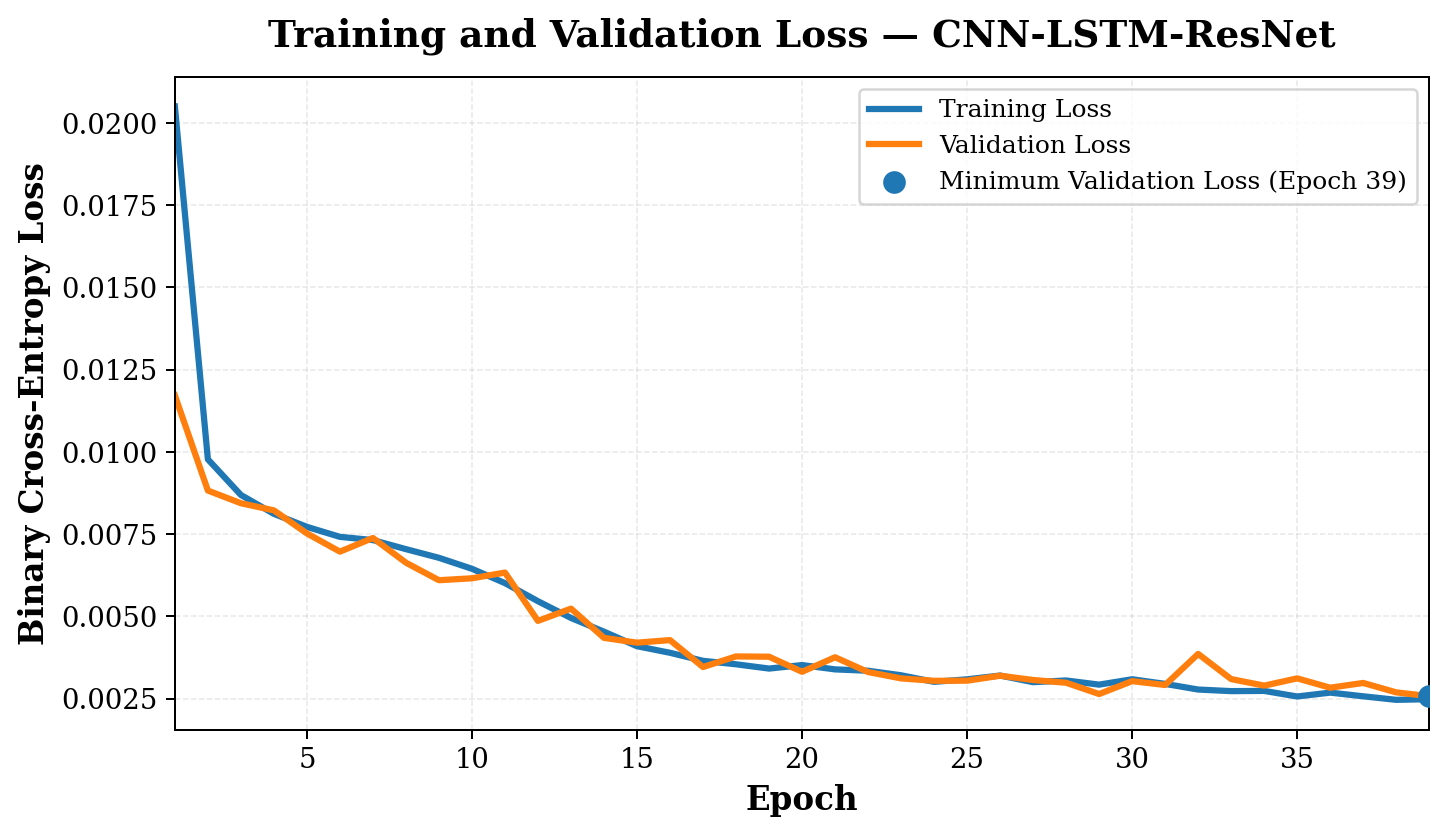


Loss figure information
-----------------------
Model                  : CNN-LSTM-ResNet
History source         : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_history/CNN-LSTM-ResNet_history.csv
Completed epochs       : 39
Best validation epoch  : 39
Training loss there    : 0.00248199
Validation loss there  : 0.00257514
Saved PNG              : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_conference_plots/CNN-LSTM-ResNet_training_validation_loss_display.png


In [ ]:
# ================================================================
# DISPLAY TRAINING AND VALIDATION LOSS
# BEST COMPLETED MODEL OR A USER-SELECTED MODEL — NO RETRAINING
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# "AUTO" selects the highest-F1 completed model with a saved history file.
# To display another model, use one of:
# "FNN", "CNN", "RNN", "GRU", "LSTM", "CNN-LSTM", "CNN-LSTM-ResNet"
LOSS_MODEL_NAME = "AUTO"


# ----------------------------------------------------------------
# 1. Select the model
# ----------------------------------------------------------------

if LOSS_MODEL_NAME == "AUTO":

    if not os.path.exists(RESULT_FILE):
        raise FileNotFoundError(
            "binary_dl_results.csv was not found. "
            "Run at least one model-training cell first."
        )

    loss_ranking = pd.read_csv(RESULT_FILE)

    if not {"Model", "F1"}.issubset(loss_ranking.columns):
        raise ValueError(
            "The result table must contain the columns 'Model' and 'F1'."
        )

    loss_ranking["F1"] = pd.to_numeric(
        loss_ranking["F1"],
        errors="coerce"
    )

    loss_ranking = (
        loss_ranking
        .dropna(subset=["Model", "F1"])
        .drop_duplicates(subset="Model", keep="last")
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )

    selected_loss_model = None

    for candidate_name in loss_ranking["Model"].astype(str):

        candidate_history_path = os.path.join(
            HISTORY_DIR,
            f"{safe_file_name(candidate_name)}_history.csv"
        )

        if os.path.exists(candidate_history_path):
            selected_loss_model = candidate_name
            break

    if selected_loss_model is None:
        raise FileNotFoundError(
            "No saved training-history CSV was found for any completed model."
        )

else:

    selected_loss_model = str(LOSS_MODEL_NAME)


history_path = os.path.join(
    HISTORY_DIR,
    f"{safe_file_name(selected_loss_model)}_history.csv"
)

if not os.path.exists(history_path):
    raise FileNotFoundError(
        f"Training-history CSV was not found for {selected_loss_model}:\n"
        f"{history_path}"
    )


# ----------------------------------------------------------------
# 2. Load and clean the saved history
# ----------------------------------------------------------------

loss_history_df = pd.read_csv(history_path)

if "epoch" in loss_history_df.columns and "Epoch" not in loss_history_df.columns:
    loss_history_df = loss_history_df.rename(columns={"epoch": "Epoch"})

if "Epoch" not in loss_history_df.columns:
    loss_history_df.insert(
        0,
        "Epoch",
        np.arange(1, len(loss_history_df) + 1)
    )
else:
    loss_history_df["Epoch"] = pd.to_numeric(
        loss_history_df["Epoch"],
        errors="coerce"
    )

    # CSVLogger generally records zero-based epochs.
    valid_epochs = loss_history_df["Epoch"].dropna()

    if not valid_epochs.empty and valid_epochs.min() == 0:
        loss_history_df["Epoch"] = loss_history_df["Epoch"] + 1


required_loss_columns = {
    "Epoch",
    "loss",
    "val_loss"
}

missing_loss_columns = required_loss_columns.difference(
    loss_history_df.columns
)

if missing_loss_columns:
    raise ValueError(
        "The history file is missing required columns: "
        f"{sorted(missing_loss_columns)}"
    )


for column_name in ["Epoch", "loss", "val_loss"]:
    loss_history_df[column_name] = pd.to_numeric(
        loss_history_df[column_name],
        errors="coerce"
    )


loss_history_df = (
    loss_history_df[
        ["Epoch", "loss", "val_loss"]
    ]
    .dropna()
    .drop_duplicates(
        subset="Epoch",
        keep="last"
    )
    .sort_values("Epoch")
    .reset_index(drop=True)
)


if loss_history_df.empty:
    raise RuntimeError(
        f"No valid loss values were found in:\n{history_path}"
    )


# ----------------------------------------------------------------
# 3. Identify the minimum-validation-loss epoch
# ----------------------------------------------------------------

best_validation_row_index = int(
    loss_history_df["val_loss"].idxmin()
)

best_validation_epoch = int(
    loss_history_df.loc[
        best_validation_row_index,
        "Epoch"
    ]
)

best_training_loss = float(
    loss_history_df.loc[
        best_validation_row_index,
        "loss"
    ]
)

best_validation_loss = float(
    loss_history_df.loc[
        best_validation_row_index,
        "val_loss"
    ]
)


# ----------------------------------------------------------------
# 4. Create and display the figure
# ----------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.2, 4.8),
    dpi=180,
    facecolor="white"
)

ax.plot(
    loss_history_df["Epoch"],
    loss_history_df["loss"],
    linewidth=2.5,
    label="Training Loss"
)

ax.plot(
    loss_history_df["Epoch"],
    loss_history_df["val_loss"],
    linewidth=2.5,
    label="Validation Loss"
)

ax.scatter(
    [best_validation_epoch],
    [best_validation_loss],
    s=65,
    zorder=5,
    label=f"Minimum Validation Loss (Epoch {best_validation_epoch})"
)

ax.axvline(
    best_validation_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.70
)

#ax.set_title(
    #f"Training and Validation Loss — {selected_loss_model}",
    #fontsize=15,
    #fontweight="bold",
    #pad=12
#)

ax.set_xlabel(
    "Epoch",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Binary Cross-Entropy Loss",
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="both",
    labelsize=11
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

ax.legend(
    fontsize=10,
    frameon=True
)

ax.set_xlim(
    max(1, int(loss_history_df["Epoch"].min())),
    int(loss_history_df["Epoch"].max())
)

fig.tight_layout()


# ----------------------------------------------------------------
# 5. Save only PNG and show the figure
# ----------------------------------------------------------------

loss_figure_path = os.path.join(
    PLOT_DIR,
    (
        f"{safe_file_name(selected_loss_model)}_"
        "training_validation_loss_display.png"
    )
)

fig.savefig(
    loss_figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


print("\nLoss figure information")
print("-----------------------")
print("Model                  :", selected_loss_model)
print("History source         :", history_path)
print("Completed epochs       :", len(loss_history_df))
print("Best validation epoch  :", best_validation_epoch)
print("Training loss there    :", f"{best_training_loss:.8f}")
print("Validation loss there  :", f"{best_validation_loss:.8f}")
print("Saved PNG              :", loss_figure_path)


In [ ]:
# ================================================================
# LOAD THE HIGHEST-F1 SAVED MODEL — NO RETRAINING
# ================================================================

import os
import pandas as pd
import tensorflow as tf

if not os.path.exists(RESULT_FILE):
    raise FileNotFoundError(
        "binary_dl_results.csv was not found. "
        "Run at least one model-training cell first."
    )

best_row = (
    pd.read_csv(RESULT_FILE)
    .dropna(subset=["F1"])
    .sort_values("F1", ascending=False)
    .iloc[0]
)

best_model_name = str(best_row["Model"])
best_model_path = os.path.join(
    MODEL_DIR,
    f"{safe_file_name(best_model_name)}.keras"
)

if not os.path.exists(best_model_path):
    available_models = sorted(
        file_name
        for file_name in os.listdir(MODEL_DIR)
        if file_name.endswith(".keras")
    )
    raise FileNotFoundError(
        f"Best model file was not found: {best_model_path}\n"
        f"Available model files: {available_models}"
    )

best_binary_model = tf.keras.models.load_model(
    best_model_path,
    compile=False
)

print("Best model:", best_model_name)
print("F1 score:", float(best_row["F1"]))
print("Loaded from:", best_model_path)
print("Input shape:", best_binary_model.input_shape)
print("Output shape:", best_binary_model.output_shape)


Best model: CNN-LSTM-ResNet
F1 score: 0.9994811668223684
Loaded from: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_models/CNN-LSTM-ResNet.keras
Input shape: (None, 79, 1)
Output shape: (None, 1)


In [ ]:
!pip install -q shap lime

import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lime.lime_tabular import LimeTabularExplainer

XAI_DIR = f'{OUT_PATH}/binary_lime_vs_shap'
os.makedirs(XAI_DIR, exist_ok=True)

print("XAI output folder:", XAI_DIR)


XAI output folder: /content/drive/MyDrive/IoMT_Thesis_2024/binary_lime_vs_shap


LIME background shape: (100, 79)

Representative samples
----------------------------------------------------------------------
Benign | Test index: 140719 | Predicted: Benign | Class probability: 0.988613
Selection: Correctly classified median-confidence sample
Attack | Test index: 326909 | Predicted: Attack | Class probability: 1.000000
Selection: Correctly classified median-confidence sample

Generating LIME explanation for Benign...

Generating LIME explanation for Attack...


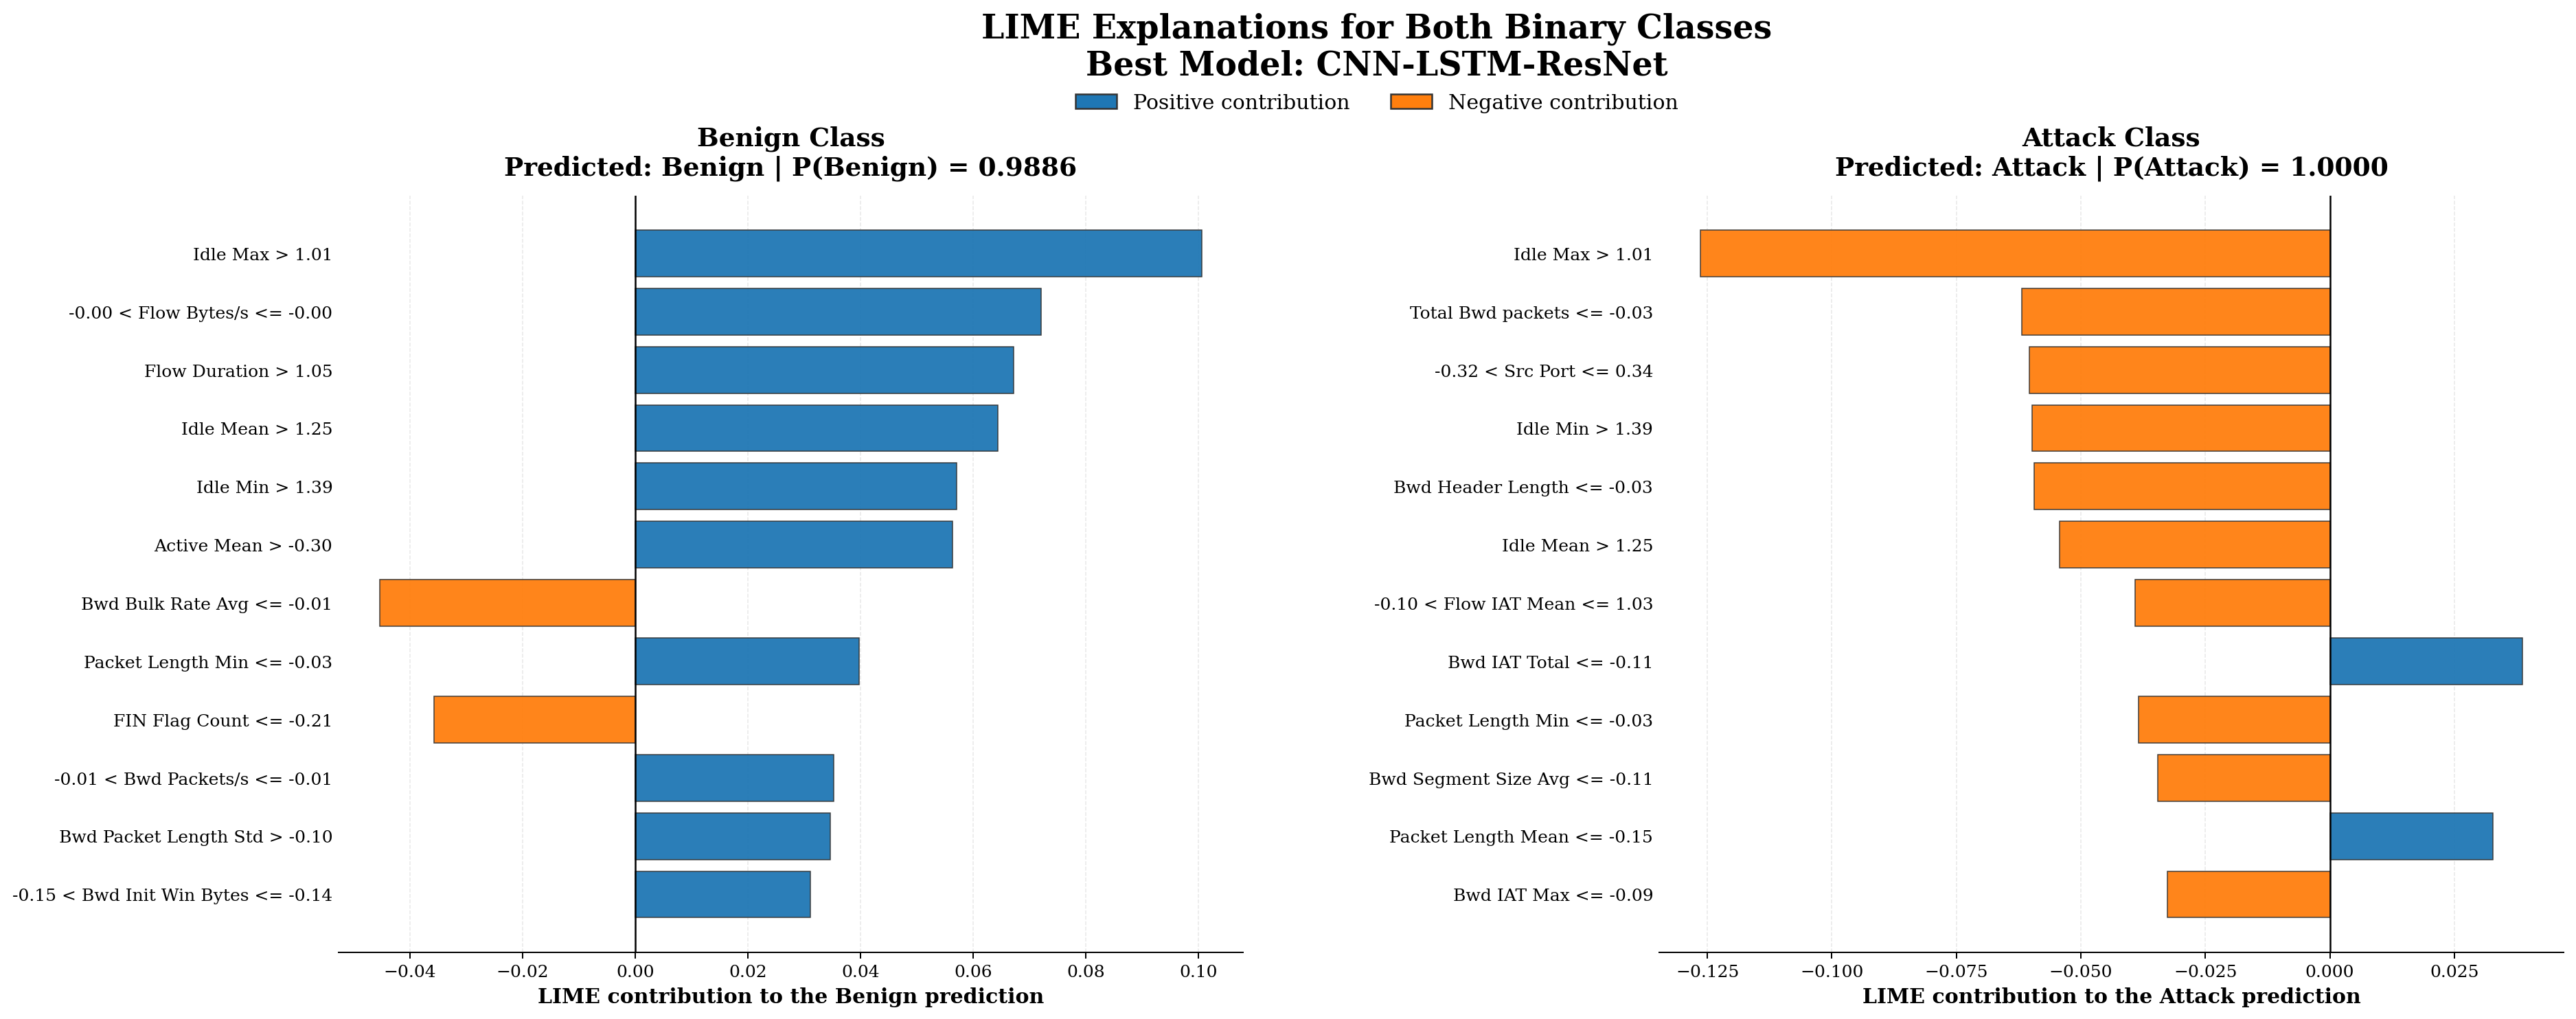


Standard Binary LIME figure saved successfully:
/content/drive/MyDrive/IoMT_Thesis_2024/binary_lime_vs_shap/CNN-LSTM-ResNet_Standard_LIME_Benign_and_Attack.png


In [ ]:
# ================================================================
# STANDARD BINARY LIME FIGURE
# BENIGN AND ATTACK IN ONE CONFERENCE-READY FIGURE
# BEST SAVED DL MODEL — NO RETRAINING
# ================================================================

import os
import gc
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch


# ----------------------------------------------------------------
# 1. Import LIME
# ----------------------------------------------------------------

try:
    from lime.lime_tabular import LimeTabularExplainer

except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "lime"
        ]
    )

    from lime.lime_tabular import LimeTabularExplainer


# ----------------------------------------------------------------
# 2. Configuration
# ----------------------------------------------------------------

RANDOM_SEED = 42

CLASS_NAMES = [
    "Benign",
    "Attack"
]

N_CLASSES = 2

BACKGROUND_PER_CLASS = 50
CANDIDATE_PER_CLASS = 200

LIME_NUM_SAMPLES = 3000
TOP_FEATURES_TO_DISPLAY = 12

POSITIVE_COLOR = "#1F77B4"   # Blue
NEGATIVE_COLOR = "#FF7F0E"   # Orange


# ----------------------------------------------------------------

def model_uses_sequence_input(model):

    input_shape = model.input_shape

    # Safety for models with multiple inputs
    if isinstance(input_shape, list):
        input_shape = input_shape[0]

    # FNN: (None, 79)       -> False
    # CNN/RNN/LSTM/etc.: (None, 79, 1) -> True
    return len(input_shape) == 3
# ----------------------------------------------------------------
# 3. Check required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "best_binary_model",
    "best_model_name",
    "X_train_scaled",
    "X_test_scaled",
    "y_train",
    "y_test",
    "feature_names",
    "model_uses_sequence_input",
    "safe_file_name",
    "XAI_DIR"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Run the binary data-preparation and best-model-loading "
        f"cells first. Missing variables: {missing_variables}"
    )


# ----------------------------------------------------------------
# 4. Prepare data
# ----------------------------------------------------------------

X_train_xai = np.asarray(
    X_train_scaled,
    dtype=np.float32
)

X_test_xai = np.asarray(
    X_test_scaled,
    dtype=np.float32
)

y_train_xai = np.asarray(
    y_train,
    dtype=np.int8
).reshape(-1)

y_test_xai = np.asarray(
    y_test,
    dtype=np.int8
).reshape(-1)

feature_names_xai = [
    str(feature)
    for feature in feature_names
]

number_of_features = X_train_xai.shape[1]

if number_of_features != len(feature_names_xai):

    raise ValueError(
        f"Feature count mismatch: data={number_of_features}, "
        f"names={len(feature_names_xai)}"
    )

os.makedirs(
    XAI_DIR,
    exist_ok=True
)

random_generator = np.random.default_rng(
    RANDOM_SEED
)


# ----------------------------------------------------------------
# 5. Model-input and prediction functions
# ----------------------------------------------------------------

def to_binary_model_input(x_2d):

    x_2d = np.asarray(
        x_2d,
        dtype=np.float32
    )

    if model_uses_sequence_input(
        best_binary_model
    ):

        return np.expand_dims(
            x_2d,
            axis=-1
        )

    return x_2d


def predict_binary_proba(x_2d):

    attack_probability = best_binary_model.predict(
        to_binary_model_input(
            x_2d
        ),
        batch_size=512,
        verbose=0
    ).reshape(-1)

    attack_probability = np.clip(
        attack_probability,
        1e-7,
        1.0 - 1e-7
    )

    return np.column_stack(
        [
            1.0 - attack_probability,
            attack_probability
        ]
    )


# ----------------------------------------------------------------
# 6. Select balanced background samples
# ----------------------------------------------------------------

background_indices = []

for class_id in range(
    N_CLASSES
):

    available_indices = np.flatnonzero(
        y_train_xai == class_id
    )

    if available_indices.size == 0:

        raise RuntimeError(
            f"No training samples found for "
            f"{CLASS_NAMES[class_id]}."
        )

    selected_count = min(
        BACKGROUND_PER_CLASS,
        available_indices.size
    )

    selected_indices = random_generator.choice(
        available_indices,
        size=selected_count,
        replace=False
    )

    background_indices.extend(
        selected_indices.tolist()
    )


background_indices = np.asarray(
    background_indices,
    dtype=np.int64
)

X_lime_background = X_train_xai[
    background_indices
]

print(
    "LIME background shape:",
    X_lime_background.shape
)


# ----------------------------------------------------------------
# 7. Select one representative sample from each class
# ----------------------------------------------------------------

representative_indices = []
representative_probabilities = []
representative_predictions = []
selection_methods = []


for class_id in range(
    N_CLASSES
):

    class_test_indices = np.flatnonzero(
        y_test_xai == class_id
    )

    if class_test_indices.size == 0:

        raise RuntimeError(
            f"No test samples found for "
            f"{CLASS_NAMES[class_id]}."
        )

    candidate_count = min(
        CANDIDATE_PER_CLASS,
        class_test_indices.size
    )

    candidate_indices = random_generator.choice(
        class_test_indices,
        size=candidate_count,
        replace=False
    )

    candidate_probability_matrix = predict_binary_proba(
        X_test_xai[
            candidate_indices
        ]
    )

    candidate_predictions = np.argmax(
        candidate_probability_matrix,
        axis=1
    )

    correct_positions = np.flatnonzero(
        candidate_predictions == class_id
    )


    if correct_positions.size > 0:

        correct_class_probabilities = (
            candidate_probability_matrix[
                correct_positions,
                class_id
            ]
        )

        median_probability = np.median(
            correct_class_probabilities
        )

        selected_position = correct_positions[
            np.argmin(
                np.abs(
                    correct_class_probabilities
                    -
                    median_probability
                )
            )
        ]

        selection_method = (
            "Correctly classified median-confidence sample"
        )


    else:

        selected_position = int(
            np.argmax(
                candidate_probability_matrix[
                    :,
                    class_id
                ]
            )
        )

        selection_method = (
            "Highest true-class probability sample"
        )


    selected_index = int(
        candidate_indices[
            selected_position
        ]
    )

    selected_probability_vector = (
        candidate_probability_matrix[
            selected_position
        ]
    )

    selected_prediction = int(
        np.argmax(
            selected_probability_vector
        )
    )


    representative_indices.append(
        selected_index
    )

    representative_probabilities.append(
        float(
            selected_probability_vector[
                class_id
            ]
        )
    )

    representative_predictions.append(
        selected_prediction
    )

    selection_methods.append(
        selection_method
    )


representative_indices = np.asarray(
    representative_indices,
    dtype=np.int64
)


print("\nRepresentative samples")
print("-" * 70)

for class_id in range(
    N_CLASSES
):

    print(
        f"{CLASS_NAMES[class_id]} | "
        f"Test index: {representative_indices[class_id]} | "
        f"Predicted: "
        f"{CLASS_NAMES[representative_predictions[class_id]]} | "
        f"Class probability: "
        f"{representative_probabilities[class_id]:.6f}"
    )

    print(
        "Selection:",
        selection_methods[class_id]
    )


# ----------------------------------------------------------------
# 8. Create the LIME explainer
# ----------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=feature_names_xai,
    class_names=CLASS_NAMES,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    random_state=RANDOM_SEED
)


# ----------------------------------------------------------------
# 9. Generate one LIME explanation for each class
# ----------------------------------------------------------------

lime_explanations = []

for class_id in range(
    N_CLASSES
):

    selected_instance = X_test_xai[
        representative_indices[class_id]
    ]

    print(
        f"\nGenerating LIME explanation for "
        f"{CLASS_NAMES[class_id]}..."
    )

    explanation = lime_explainer.explain_instance(
        data_row=selected_instance,
        predict_fn=predict_binary_proba,
        labels=(class_id,),
        num_features=min(
            TOP_FEATURES_TO_DISPLAY,
            number_of_features
        ),
        num_samples=LIME_NUM_SAMPLES
    )

    lime_explanations.append(
        explanation
    )


# ----------------------------------------------------------------
# 10. Create the conventional two-panel LIME figure
# ----------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(20, 8.5),
    dpi=180,
    facecolor="white"
)


for class_id, axis in enumerate(
    axes
):

    explanation_list = lime_explanations[
        class_id
    ].as_list(
        label=class_id
    )

    feature_conditions = [
        str(item[0])
        for item in explanation_list
    ]

    contribution_values = np.asarray(
        [
            float(item[1])
            for item in explanation_list
        ],
        dtype=np.float64
    )


    # Arrange from smaller to larger absolute contribution.
    order = np.argsort(
        np.abs(
            contribution_values
        )
    )

    feature_conditions = [
        feature_conditions[index]
        for index in order
    ]

    contribution_values = contribution_values[
        order
    ]


    bar_colors = [
        POSITIVE_COLOR
        if contribution >= 0
        else NEGATIVE_COLOR
        for contribution in contribution_values
    ]


    y_positions = np.arange(
        len(
            feature_conditions
        )
    )


    axis.barh(
        y_positions,
        contribution_values,
        color=bar_colors,
        edgecolor="#333333",
        linewidth=0.6,
        alpha=0.95
    )


    axis.set_yticks(
        y_positions
    )

    axis.set_yticklabels(
        feature_conditions,
        fontsize=10
    )


    axis.axvline(
        0,
        color="black",
        linewidth=1.0
    )


    axis.set_title(
        (
            f"{CLASS_NAMES[class_id]} Class\n"
            f"Predicted: "
            f"{CLASS_NAMES[representative_predictions[class_id]]} | "
            f"P({CLASS_NAMES[class_id]}) = "
            f"{representative_probabilities[class_id]:.4f}"
        ),
        fontsize=15,
        fontweight="bold",
        pad=12
    )


    axis.set_xlabel(
        (
            f"LIME contribution to the "
            f"{CLASS_NAMES[class_id]} prediction"
        ),
        fontsize=12,
        fontweight="bold"
    )


    axis.tick_params(
        axis="x",
        labelsize=10
    )

    axis.tick_params(
        axis="y",
        length=0
    )


    axis.xaxis.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.30
    )

    axis.set_axisbelow(
        True
    )


    axis.spines["top"].set_visible(
        False
    )

    axis.spines["right"].set_visible(
        False
    )

    axis.spines["left"].set_visible(
        False
    )


# ----------------------------------------------------------------
# 11. Add common title and legend
# ----------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=POSITIVE_COLOR,
        edgecolor="#333333",
        label="Positive contribution"
    ),
    Patch(
        facecolor=NEGATIVE_COLOR,
        edgecolor="#333333",
        label="Negative contribution"
    )
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=False,
    fontsize=12
)


fig.suptitle(
    (
        "LIME Explanations for Both Binary Classes\n"
        f"Best Model: {best_model_name}"
    ),
    fontsize=19,
    fontweight="bold",
    y=0.995
)


fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.10,
    top=0.82,
    wspace=0.46
)


# ----------------------------------------------------------------
# 12. Save only the PNG
# ----------------------------------------------------------------

lime_png_path = os.path.join(
    XAI_DIR,
    (
        f"{safe_file_name(best_model_name)}_"
        "Standard_LIME_Benign_and_Attack.png"
    )
)


fig.savefig(
    lime_png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()
plt.close(fig)

gc.collect()


print("\nStandard Binary LIME figure saved successfully:")
print(lime_png_path)

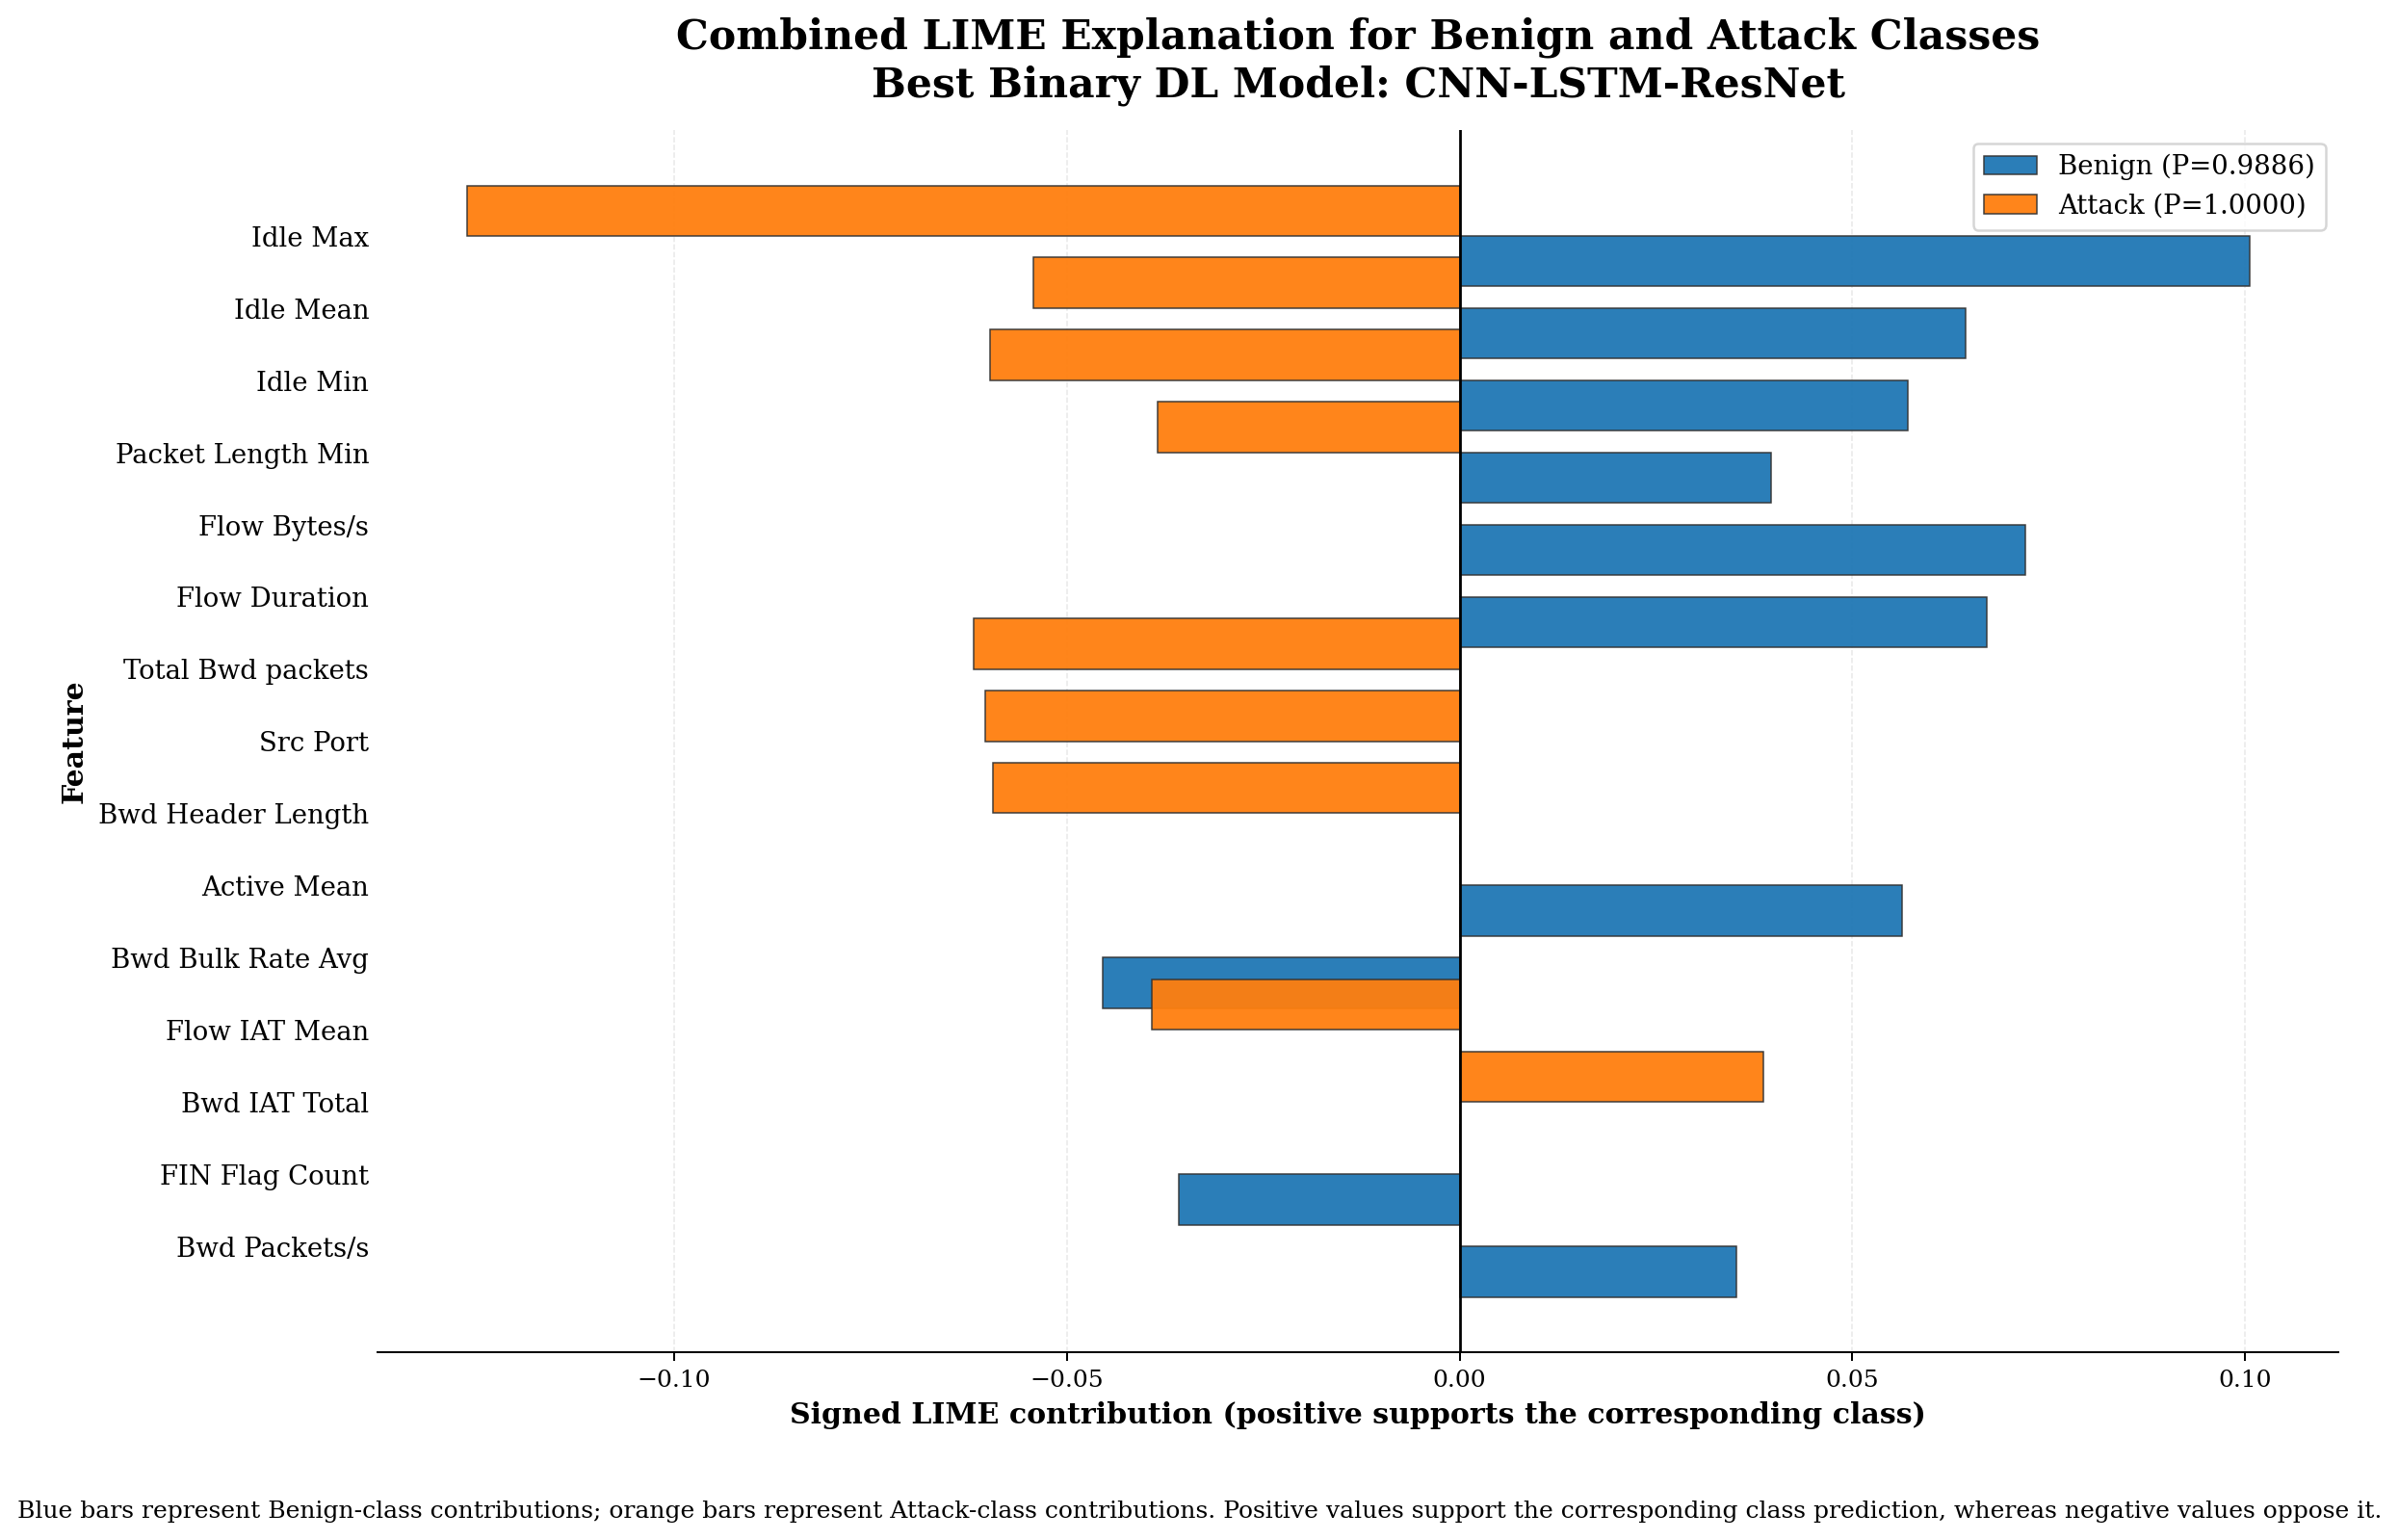


Combined Binary LIME figure saved:
/content/drive/MyDrive/IoMT_Thesis_2024/binary_lime_vs_shap/CNN-LSTM-ResNet_Combined_LIME_Benign_Attack.png

Combined Binary LIME values saved:
/content/drive/MyDrive/IoMT_Thesis_2024/binary_lime_vs_shap/CNN-LSTM-ResNet_Combined_LIME_Benign_Attack_values.csv


In [ ]:
# ================================================================
# COMBINED BINARY LIME FIGURE
# BENIGN AND ATTACK CONTRIBUTIONS IN ONE SINGLE PLOT
# NO RETRAINING
# ================================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch


# ----------------------------------------------------------------
# 1. Configuration
# ----------------------------------------------------------------

TOP_FEATURES_COMBINED = 15

BENIGN_COLOR = "#1F77B4"   # Blue
ATTACK_COLOR = "#FF7F0E"   # Orange


# ----------------------------------------------------------------
# 2. Check required variables
# ----------------------------------------------------------------

required_variables = [
    "lime_explanations",
    "feature_names_xai",
    "best_model_name",
    "representative_probabilities",
    "XAI_DIR",
    "safe_file_name"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Run the Binary LIME preparation and explanation cells "
        f"first. Missing variables: {missing_variables}"
    )


if len(lime_explanations) != 2:

    raise ValueError(
        "Exactly two LIME explanations are required: "
        "Benign and Attack."
    )


CLASS_NAMES = [
    "Benign",
    "Attack"
]

number_of_features = len(
    feature_names_xai
)


# ----------------------------------------------------------------
# 3. Extract signed LIME contribution by original feature index
# ----------------------------------------------------------------

lime_signed_contributions = np.zeros(
    (
        2,
        number_of_features
    ),
    dtype=np.float64
)


for class_id in range(2):

    explanation_map = lime_explanations[
        class_id
    ].as_map().get(
        class_id,
        []
    )

    for feature_index, contribution in explanation_map:

        feature_index = int(
            feature_index
        )

        if (
            0
            <= feature_index
            < number_of_features
        ):

            lime_signed_contributions[
                class_id,
                feature_index
            ] = float(
                contribution
            )


# ----------------------------------------------------------------
# 4. Select common top features across both classes
# ----------------------------------------------------------------

combined_absolute_importance = np.mean(
    np.abs(
        lime_signed_contributions
    ),
    axis=0
)


available_feature_count = int(
    np.count_nonzero(
        combined_absolute_importance
    )
)


if available_feature_count == 0:

    raise RuntimeError(
        "No non-zero LIME contributions were found."
    )


number_of_features_to_plot = min(
    TOP_FEATURES_COMBINED,
    available_feature_count
)


top_feature_indices = np.argsort(
    combined_absolute_importance
)[
    -number_of_features_to_plot:
]


# Arrange smaller contribution at the bottom and larger at the top.
top_feature_indices = top_feature_indices[
    np.argsort(
        combined_absolute_importance[
            top_feature_indices
        ]
    )
]


top_feature_names = [
    str(
        feature_names_xai[
            feature_index
        ]
    )
    for feature_index in top_feature_indices
]


benign_contributions = lime_signed_contributions[
    0,
    top_feature_indices
]

attack_contributions = lime_signed_contributions[
    1,
    top_feature_indices
]


# ----------------------------------------------------------------
# 5. Create a numerical table
# ----------------------------------------------------------------

combined_lime_table = pd.DataFrame(
    {
        "Feature": top_feature_names,
        "Benign LIME Contribution":
            benign_contributions,
        "Attack LIME Contribution":
            attack_contributions,
        "Mean Absolute Contribution":
            combined_absolute_importance[
                top_feature_indices
            ]
    }
)


# ----------------------------------------------------------------
# 6. Create one combined horizontal bar figure
# ----------------------------------------------------------------

y_positions = np.arange(
    number_of_features_to_plot
)

bar_height = 0.70


fig, axis = plt.subplots(
    figsize=(13.5, 9),
    dpi=180,
    facecolor="white"
)


axis.barh(
    y_positions - bar_height / 2,
    benign_contributions,
    height=bar_height,
    color=BENIGN_COLOR,
    edgecolor="#333333",
    linewidth=0.6,
    alpha=0.95,
    label=(
        f"Benign "
        f"(P={representative_probabilities[0]:.4f})"
    )
)


axis.barh(
    y_positions + bar_height / 2,
    attack_contributions,
    height=bar_height,
    color=ATTACK_COLOR,
    edgecolor="#333333",
    linewidth=0.6,
    alpha=0.95,
    label=(
        f"Attack "
        f"(P={representative_probabilities[1]:.4f})"
    )
)


# ----------------------------------------------------------------
# 7. Format the figure
# ----------------------------------------------------------------

axis.set_yticks(
    y_positions
)

axis.set_yticklabels(
    top_feature_names,
    fontsize=11
)


axis.axvline(
    0,
    color="black",
    linewidth=1.1
)


# axis.set_title(
    #(
        #"Combined LIME Explanation for Benign and Attack Classes\n"
        #f"Best Binary DL Model: {best_model_name}"
    #),
    #fontsize=17,
    #fontweight="bold",
    #pad=14
#)


axis.set_xlabel(
    (
        "Signed LIME contribution "
        "(positive supports the corresponding class)"
    ),
    fontsize=12,
    fontweight="bold"
)


axis.set_ylabel(
    "Feature",
    fontsize=12,
    fontweight="bold"
)


axis.tick_params(
    axis="x",
    labelsize=10
)

axis.tick_params(
    axis="y",
    length=0
)


axis.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

axis.set_axisbelow(
    True
)


axis.spines["top"].set_visible(
    False
)

axis.spines["right"].set_visible(
    False
)

axis.spines["left"].set_visible(
    False
)


axis.legend(
    loc="best",
    fontsize=11,
    frameon=True
)


figure_note = (
    "Blue bars represent Benign-class contributions; "
    "orange bars represent Attack-class contributions. "
    "Positive values support the corresponding class prediction, "
    "whereas negative values oppose it."
)


fig.text(
    0.5,
    0.015,
    figure_note,
    ha="center",
    va="bottom",
    fontsize=10
)


fig.tight_layout(
    rect=[
        0,
        0.055,
        1,
        1
    ]
)


# ----------------------------------------------------------------
# 8. Save only the PNG
# ----------------------------------------------------------------

os.makedirs(
    XAI_DIR,
    exist_ok=True
)


combined_lime_png_path = os.path.join(
    XAI_DIR,
    (
        f"{safe_file_name(best_model_name)}_"
        "Combined_LIME_Benign_Attack.png"
    )
)


fig.savefig(
    combined_lime_png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()
plt.close(fig)


# ----------------------------------------------------------------
# 9. Save the displayed LIME values
# ----------------------------------------------------------------

combined_lime_csv_path = os.path.join(
    XAI_DIR,
    (
        f"{safe_file_name(best_model_name)}_"
        "Combined_LIME_Benign_Attack_values.csv"
    )
)


combined_lime_table.to_csv(
    combined_lime_csv_path,
    index=False
)


gc.collect()


print("\nCombined Binary LIME figure saved:")
print(combined_lime_png_path)

print("\nCombined Binary LIME values saved:")
print(combined_lime_csv_path)

In [ ]:
# ================================================================
# BINARY DL McNEMAR TEST
# BEST F1 MODEL VS OTHER COMPLETED MODELS — NO RETRAINING
# ================================================================

try:
    from statsmodels.stats.contingency_tables import mcnemar
    from statsmodels.stats.multitest import multipletests
except ImportError:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'statsmodels'
    ])
    from statsmodels.stats.contingency_tables import mcnemar
    from statsmodels.stats.multitest import multipletests

ALPHA = 0.05

# None compares the best model with every other completed model.
# Use 4 to compare only with the next four ranked models.
NUMBER_OF_COMPARISON_MODELS = None

MCNEMAR_OUTPUT_FILE = f'{OUT_PATH}/binary_dl_best_vs_other_models_mcnemar_holm.csv'


def load_binary_prediction_cache(model_name):
    cache_path = artifact_paths(model_name)['cache']

    if not os.path.exists(cache_path):
        raise FileNotFoundError(
            f'Prediction cache was not found for {model_name}:\n{cache_path}'
        )

    with np.load(cache_path, allow_pickle=False) as saved:
        y_true_cache = np.asarray(saved['y_true'], dtype=np.int8).reshape(-1)

        if 'y_pred' in saved.files:
            y_pred_cache = np.asarray(saved['y_pred'], dtype=np.int8).reshape(-1)
        elif 'y_prob' in saved.files:
            y_pred_cache = (
                np.asarray(saved['y_prob'], dtype=np.float32).reshape(-1) >= 0.5
            ).astype(np.int8)
        else:
            raise KeyError(
                f"Neither 'y_pred' nor 'y_prob' exists in {cache_path}."
            )

    if len(y_true_cache) != len(y_pred_cache):
        raise ValueError(
            f'{model_name}: y_true and y_pred lengths do not match.'
        )

    return y_true_cache, y_pred_cache


if not os.path.exists(RESULT_FILE):
    raise FileNotFoundError('binary_dl_results.csv was not found.')

ranking_table = pd.read_csv(RESULT_FILE)
ranking_table['F1'] = pd.to_numeric(ranking_table['F1'], errors='coerce')
ranking_table = (
    ranking_table
    .dropna(subset=['Model', 'F1'])
    .drop_duplicates(subset='Model', keep='last')
    .sort_values('F1', ascending=False)
    .reset_index(drop=True)
)

completed_models = [
    str(model_name)
    for model_name in ranking_table['Model']
    if os.path.exists(artifact_paths(str(model_name))['cache'])
]

if len(completed_models) < 2:
    raise RuntimeError(
        'At least two completed models with prediction caches are required.'
    )

reference_model_name = completed_models[0]
comparison_model_names = completed_models[1:]

if NUMBER_OF_COMPARISON_MODELS is not None:
    comparison_model_names = comparison_model_names[
        :NUMBER_OF_COMPARISON_MODELS
    ]

reference_y_true, reference_y_pred = load_binary_prediction_cache(
    reference_model_name
)
reference_correct = reference_y_pred == reference_y_true

print('Reference model:', reference_model_name)
print('Paired test observations:', f'{len(reference_y_true):,}')
print('Comparison models:', comparison_model_names)

statistical_rows = []

for comparison_model_name in comparison_model_names:
    comparison_y_true, comparison_y_pred = load_binary_prediction_cache(
        comparison_model_name
    )

    if not np.array_equal(comparison_y_true, reference_y_true):
        raise ValueError(
            f'The y_true order for {comparison_model_name} does not match '
            f'{reference_model_name}; paired McNemar testing is invalid.'
        )

    comparison_correct = comparison_y_pred == comparison_y_true

    reference_correct_comparison_wrong = int(np.sum(
        reference_correct & ~comparison_correct
    ))
    reference_wrong_comparison_correct = int(np.sum(
        ~reference_correct & comparison_correct
    ))
    both_correct = int(np.sum(reference_correct & comparison_correct))
    both_wrong = int(np.sum(~reference_correct & ~comparison_correct))

    discordant_predictions = (
        reference_correct_comparison_wrong
        + reference_wrong_comparison_correct
    )

    table = np.asarray([
        [both_correct, reference_correct_comparison_wrong],
        [reference_wrong_comparison_correct, both_wrong]
    ], dtype=np.int64)

    if discordant_predictions == 0:
        test_method = 'No discordant predictions'
        statistic = 0.0
        p_value = 1.0
    elif discordant_predictions < 25:
        result = mcnemar(table, exact=True, correction=False)
        test_method = 'Exact McNemar test'
        statistic = float(result.statistic)
        p_value = float(result.pvalue)
    else:
        result = mcnemar(table, exact=False, correction=True)
        test_method = 'McNemar chi-square with correction'
        statistic = float(result.statistic)
        p_value = float(result.pvalue)

    statistical_rows.append({
        'Reference Model': reference_model_name,
        'Comparison Model': comparison_model_name,
        'Reference Correct / Comparison Wrong': reference_correct_comparison_wrong,
        'Reference Wrong / Comparison Correct': reference_wrong_comparison_correct,
        'Discordant Predictions': discordant_predictions,
        'Test Method': test_method,
        'Statistic': statistic,
        'P-value': p_value,
        'Significance (α=0.05)': (
            'Statistically significant'
            if p_value < ALPHA
            else 'Not statistically significant'
        )
    })

mcnemar_results = pd.DataFrame(statistical_rows)

holm_reject, holm_adjusted_p_values, _, _ = multipletests(
    mcnemar_results['P-value'].to_numpy(dtype=float),
    alpha=ALPHA,
    method='holm'
)

mcnemar_results['Holm-adjusted P-value'] = holm_adjusted_p_values
mcnemar_results['Significance after Holm correction'] = np.where(
    holm_reject,
    'Statistically significant',
    'Not statistically significant'
)

conclusions = []
for row_index, row in mcnemar_results.iterrows():
    b = int(row['Reference Correct / Comparison Wrong'])
    c = int(row['Reference Wrong / Comparison Correct'])
    comparison_name = str(row['Comparison Model'])

    if bool(holm_reject[row_index]):
        if b > c:
            conclusion = (
                f'{reference_model_name} made significantly more correct '
                f'predictions than {comparison_name} after Holm correction.'
            )
        elif c > b:
            conclusion = (
                f'{comparison_name} made significantly more correct '
                f'predictions than {reference_model_name} after Holm correction.'
            )
        else:
            conclusion = (
                'A significant difference was detected without a directional advantage.'
            )
    else:
        conclusion = (
            f'No statistically significant difference was found between '
            f'{reference_model_name} and {comparison_name} after Holm correction.'
        )

    conclusions.append(conclusion)

mcnemar_results['Conclusion'] = conclusions

final_columns = [
    'Reference Model',
    'Comparison Model',
    'Reference Correct / Comparison Wrong',
    'Reference Wrong / Comparison Correct',
    'Discordant Predictions',
    'Test Method',
    'Statistic',
    'P-value',
    'Holm-adjusted P-value',
    'Significance (α=0.05)',
    'Significance after Holm correction',
    'Conclusion'
]

mcnemar_results = mcnemar_results[final_columns]
mcnemar_results.to_csv(MCNEMAR_OUTPUT_FILE, index=False)

display(
    mcnemar_results.style.format({
        'Statistic': '{:.6f}',
        'P-value': '{:.6e}',
        'Holm-adjusted P-value': '{:.6e}'
    })
)

print('McNemar results saved:', MCNEMAR_OUTPUT_FILE)


Reference model: CNN-LSTM-ResNet
Paired test observations: 649,474
Comparison models: ['GRU', 'CNN-LSTM', 'FNN', 'RNN', 'LSTM', 'CNN']


,Reference Model,Comparison Model,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Discordant Predictions,Test Method,Statistic,P-value,Holm-adjusted P-value,Significance (α=0.05),Significance after Holm correction,Conclusion
0,CNN-LSTM-ResNet,GRU,463,135,598,McNemar chi-square with correction,178.811037,8.810973e-41,8.810973e-41,Statistically significant,Statistically significant,CNN-LSTM-ResNet made significantly more correct predictions than GRU after Holm correction.
1,CNN-LSTM-ResNet,CNN-LSTM,505,99,604,McNemar chi-square with correction,271.564570,5.175135e-61,1.035027e-60,Statistically significant,Statistically significant,CNN-LSTM-ResNet made significantly more correct predictions than CNN-LSTM after Holm correction.
2,CNN-LSTM-ResNet,FNN,889,109,998,McNemar chi-square with correction,608.057114,2.960274e-134,8.880821e-134,Statistically significant,Statistically significant,CNN-LSTM-ResNet made significantly more correct predictions than FNN after Holm correction.
3,CNN-LSTM-ResNet,RNN,1362,120,1482,McNemar chi-square with correction,1039.190958,5.441593e-228,2.176637e-227,Statistically significant,Statistically significant,CNN-LSTM-ResNet made significantly more correct predictions than RNN after Holm correction.
4,CNN-LSTM-ResNet,LSTM,1410,121,1531,McNemar chi-square with correction,1083.568909,1.230589e-237,6.152943e-237,Statistically significant,Statistically significant,CNN-LSTM-ResNet made significantly more correct predictions than LSTM after Holm correction.
5,CNN-LSTM-ResNet,CNN,1523,131,1654,McNemar chi-square with correction,1169.819226,2.210512e-256,1.326307e-255,Statistically significant,Statistically significant,CNN-LSTM-ResNet made significantly more correct predictions than CNN after Holm correction.


McNemar results saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_best_vs_other_models_mcnemar_holm.csv


In [ ]:
# ================================================================
# EXPORT BEST BINARY DL MODEL WEIGHTS AND NETRON FILES
# NO RETRAINING — NO MODEL-SUMMARY TEXT FILE
# ================================================================

if not os.path.exists(RESULT_FILE):
    raise FileNotFoundError('binary_dl_results.csv was not found.')

netron_results = pd.read_csv(RESULT_FILE)
netron_results['F1'] = pd.to_numeric(netron_results['F1'], errors='coerce')
netron_results = (
    netron_results
    .dropna(subset=['Model', 'F1'])
    .drop_duplicates(subset='Model', keep='last')
    .sort_values('F1', ascending=False)
    .reset_index(drop=True)
)

if netron_results.empty:
    raise RuntimeError('No completed model was found in the result table.')

netron_best_model_name = str(netron_results.iloc[0]['Model'])
netron_best_model_f1 = float(netron_results.iloc[0]['F1'])
netron_safe_name = safe_file_name(netron_best_model_name)
netron_original_model_path = artifact_paths(netron_best_model_name)['model']

if not os.path.exists(netron_original_model_path):
    raise FileNotFoundError(
        'Best model file was not found:\n' + netron_original_model_path
    )

tf.keras.backend.clear_session()
netron_best_model = tf.keras.models.load_model(
    netron_original_model_path,
    compile=False
)

weights_only_path = os.path.join(
    NETRON_EXPORT_DIR,
    f'{netron_safe_name}.weights.h5'
)
netron_best_model.save_weights(weights_only_path)

netron_keras_path = os.path.join(
    NETRON_EXPORT_DIR,
    f'{netron_safe_name}_Netron.keras'
)
shutil.copy2(netron_original_model_path, netron_keras_path)

netron_h5_path = os.path.join(
    NETRON_EXPORT_DIR,
    f'{netron_safe_name}_Netron.h5'
)
netron_best_model.save(netron_h5_path, include_optimizer=False)

total_parameters = int(netron_best_model.count_params())
trainable_parameters = int(sum(
    np.prod(variable.shape)
    for variable in netron_best_model.trainable_weights
))
non_trainable_parameters = int(sum(
    np.prod(variable.shape)
    for variable in netron_best_model.non_trainable_weights
))

parameter_summary_df = pd.DataFrame([{
    'Model': netron_best_model_name,
    'F1': netron_best_model_f1,
    'Input Shape': str(netron_best_model.input_shape),
    'Output Shape': str(netron_best_model.output_shape),
    'Total Parameters': total_parameters,
    'Trainable Parameters': trainable_parameters,
    'Non-trainable Parameters': non_trainable_parameters
}])

parameter_summary_path = os.path.join(
    NETRON_EXPORT_DIR,
    f'{netron_safe_name}_parameter_summary.csv'
)
parameter_summary_df.to_csv(parameter_summary_path, index=False)

weight_statistics_rows = []

for layer_index, layer in enumerate(netron_best_model.layers):
    if not layer.weights:
        weight_statistics_rows.append({
            'Layer Index': layer_index,
            'Layer Name': layer.name,
            'Layer Type': layer.__class__.__name__,
            'Weight Tensor': 'No weights',
            'Tensor Shape': '',
            'Parameter Count': 0,
            'Data Type': '',
            'Minimum': np.nan,
            'Maximum': np.nan,
            'Mean': np.nan,
            'Standard Deviation': np.nan,
            'L1 Norm': np.nan,
            'L2 Norm': np.nan
        })
        continue

    for weight_tensor in layer.weights:
        weight_array = np.asarray(weight_tensor.numpy())
        weight_float = weight_array.astype(np.float64, copy=False)

        weight_statistics_rows.append({
            'Layer Index': layer_index,
            'Layer Name': layer.name,
            'Layer Type': layer.__class__.__name__,
            'Weight Tensor': weight_tensor.name,
            'Tensor Shape': str(tuple(weight_array.shape)),
            'Parameter Count': int(weight_array.size),
            'Data Type': str(weight_array.dtype),
            'Minimum': float(np.min(weight_float)),
            'Maximum': float(np.max(weight_float)),
            'Mean': float(np.mean(weight_float)),
            'Standard Deviation': float(np.std(weight_float)),
            'L1 Norm': float(np.sum(np.abs(weight_float))),
            'L2 Norm': float(np.linalg.norm(weight_float.reshape(-1)))
        })

weight_statistics_df = pd.DataFrame(weight_statistics_rows)
weight_statistics_path = os.path.join(
    NETRON_EXPORT_DIR,
    f'{netron_safe_name}_weight_statistics.csv'
)
weight_statistics_df.to_csv(weight_statistics_path, index=False)

display(parameter_summary_df)
display(weight_statistics_df)

print('=' * 72)
print('NETRON EXPORT COMPLETED')
print('=' * 72)
print('Best model:', netron_best_model_name)
print('Netron Keras file:', netron_keras_path)
print('Netron H5 file   :', netron_h5_path)
print('Weights-only file:', weights_only_path)
print('Parameter CSV    :', parameter_summary_path)
print('Weight stats CSV :', weight_statistics_path)
print('No model-summary TXT file was created.')


,Model,F1,Input Shape,Output Shape,Total Parameters,Trainable Parameters,Non-trainable Parameters
0,CNN-LSTM-ResNet,0.999481,"(None, 79, 1)","(None, 1)",60097,60097,0


,Layer Index,Layer Name,Layer Type,Weight Tensor,Tensor Shape,Parameter Count,Data Type,Minimum,Maximum,Mean,Standard Deviation,L1 Norm,L2 Norm
0,0,input_layer,InputLayer,No weights,,0,,NaN,NaN,NaN,NaN,NaN,NaN
1,1,conv1d,Conv1D,kernel,"(3, 1, 64)",192,float32,-0.554878,0.529642,-0.047584,0.232533,38.361331,3.288840
2,1,conv1d,Conv1D,bias,"(64,)",64,float32,-0.257728,0.067292,-0.052707,0.077867,4.600996,0.752221
3,2,conv1d_1,Conv1D,kernel,"(3, 64, 64)",12288,float32,-1.932540,0.764948,-0.077962,0.214426,1986.801090,25.291683
4,2,conv1d_1,Conv1D,bias,"(64,)",64,float32,-0.234019,0.218325,-0.004417,0.110565,5.867675,0.885224
5,3,conv1d_2,Conv1D,kernel,"(3, 64, 64)",12288,float32,-1.882094,0.764047,-0.064746,0.209090,1932.738524,24.263680
6,3,conv1d_2,Conv1D,bias,"(64,)",64,float32,-0.416124,0.202971,-0.092470,0.128063,7.936215,1.263667
7,4,add,Add,No weights,,0,,NaN,NaN,NaN,NaN,NaN,NaN
8,5,activation,Activation,No weights,,0,,NaN,NaN,NaN,NaN,NaN,NaN
9,6,max_pooling1d,MaxPooling1D,No weights,,0,,NaN,NaN,NaN,NaN,NaN,NaN


NETRON EXPORT COMPLETED
Best model: CNN-LSTM-ResNet
Netron Keras file: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_netron_exports/CNN-LSTM-ResNet_Netron.keras
Netron H5 file   : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_netron_exports/CNN-LSTM-ResNet_Netron.h5
Weights-only file: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_netron_exports/CNN-LSTM-ResNet.weights.h5
Parameter CSV    : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_netron_exports/CNN-LSTM-ResNet_parameter_summary.csv
Weight stats CSV : /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_netron_exports/CNN-LSTM-ResNet_weight_statistics.csv
No model-summary TXT file was created.
